In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

save_path = "graphs"
os.makedirs(save_path, exist_ok=True)


sns.set_style("whitegrid")
df = pd.read_csv('data/HeartFailureDataset.csv')
df["age_years"] = (df["age"] / 365).astype(int)

In [12]:
def save_and_show(name): # Сохрняем графики в папку в формате PNG
    plt.tight_layout()
    plt.savefig(f"graphs_analysis/{name}.png", dpi=300)
    plt.show()
    plt.close()

<h1>Анализ данных в графиках</h1>

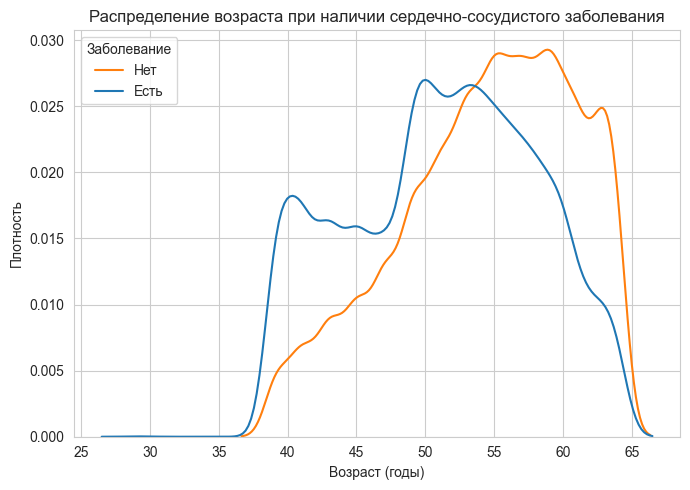

In [13]:
plt.figure(figsize=(7,5))
sns.kdeplot(data=df, x="age_years", hue="cardio", fill=False)
plt.title("Распределение возраста при наличии сердечно-сосудистого заболевания")
plt.xlabel("Возраст (годы)")
plt.ylabel("Плотность")
plt.legend(title="Заболевание", labels=["Нет", "Есть"])
save_and_show("age_vs_cardio")

<Figure size 700x500 with 0 Axes>

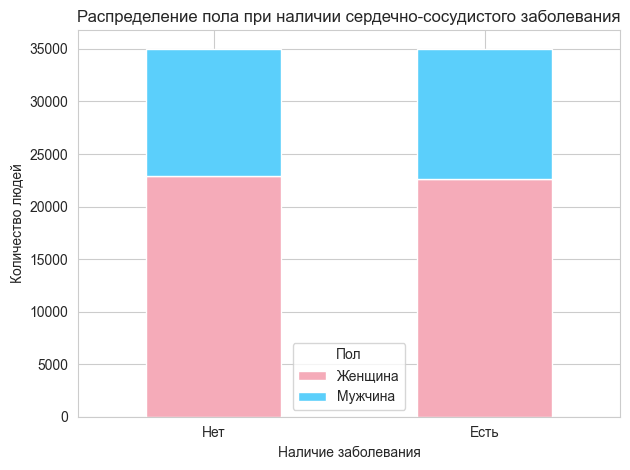

In [14]:
plt.figure(figsize=(7,5))
gender_cardio = pd.crosstab(df["cardio"], df["gender"])
gender_cardio.plot(
    kind="bar",
    stacked=True,
    color=["#F5ABB9", "#5BCFFB"]
)
plt.title("Распределение пола при наличии сердечно-сосудистого заболевания")
plt.xlabel("Наличие заболевания")
plt.ylabel("Количество людей")
plt.xticks([0,1], ["Нет", "Есть"], rotation=0)
plt.legend(["Женщина", "Мужчина"], title="Пол")
save_and_show("gender_vs_cardio")

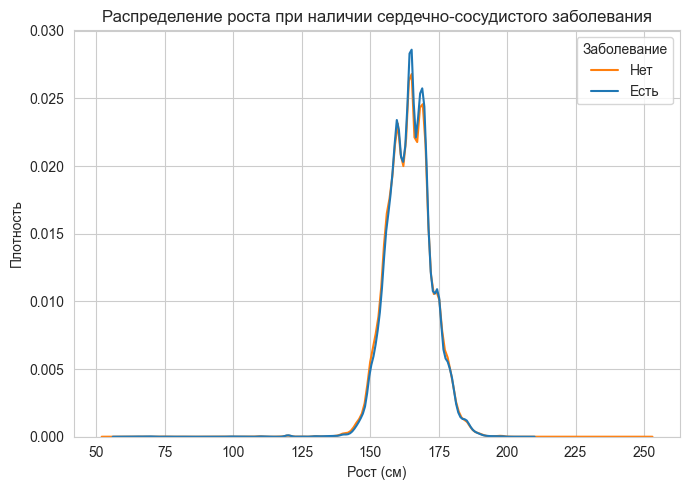

In [15]:
plt.figure(figsize=(7,5))
sns.kdeplot(data=df, x="height", hue="cardio")
plt.title("Распределение роста при наличии сердечно-сосудистого заболевания")
plt.xlabel("Рост (см)")
plt.ylabel("Плотность")
plt.legend(title="Заболевание", labels=["Нет", "Есть"])
save_and_show("height_vs_cardio")

<Figure size 700x500 with 0 Axes>

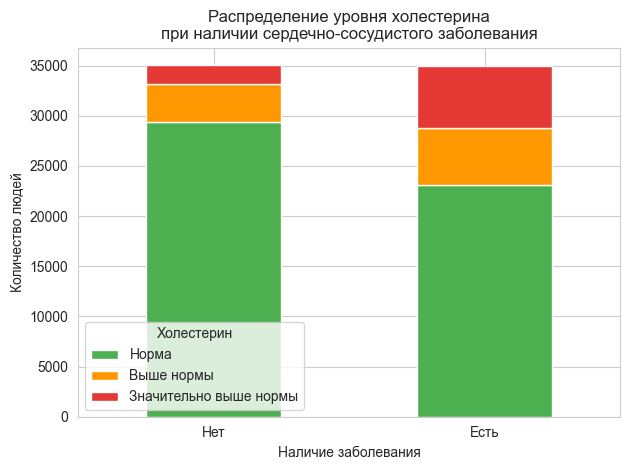

In [16]:
plt.figure(figsize=(7,5))
chol_cardio = pd.crosstab(df["cardio"], df["cholesterol"])
chol_cardio.plot(
    kind="bar",
    stacked=True,
    color=["#4CAF50", "#FF9800", "#E53935"]
)
plt.title("Распределение уровня холестерина\nпри наличии сердечно-сосудистого заболевания")
plt.xlabel("Наличие заболевания")
plt.ylabel("Количество людей")
plt.xticks([0,1], ["Нет", "Есть"], rotation=0)
plt.legend(
    ["Норма", "Выше нормы", "Значительно выше нормы"],
    title="Холестерин"
)
save_and_show("cholesterol_vs_cardio")

<Figure size 700x500 with 0 Axes>

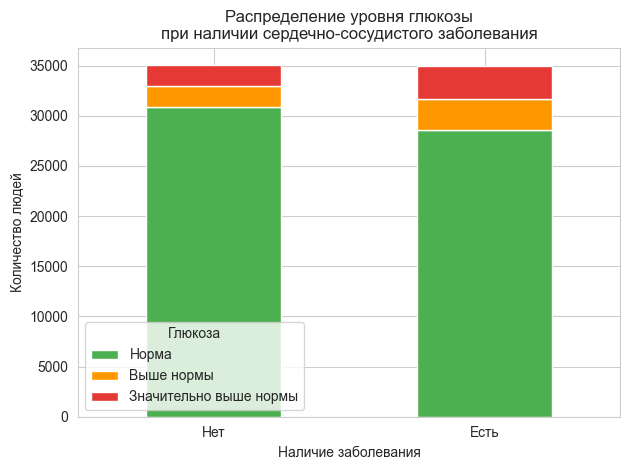

In [17]:
plt.figure(figsize=(7,5))
gluc_cardio = pd.crosstab(df["cardio"], df["gluc"])
gluc_cardio.plot(
    kind="bar",
    stacked=True,
    color=["#4CAF50", "#FF9800", "#E53935"]
)
plt.title("Распределение уровня глюкозы\nпри наличии сердечно-сосудистого заболевания")
plt.xlabel("Наличие заболевания")
plt.ylabel("Количество людей")
plt.xticks([0,1], ["Нет", "Есть"], rotation=0)
plt.legend(
    ["Норма", "Выше нормы", "Значительно выше нормы"],
    title="Глюкоза"
)
save_and_show("glucose_vs_cardio")

<h2>CVD - Сердечно-сосудистые заболевания</h2>

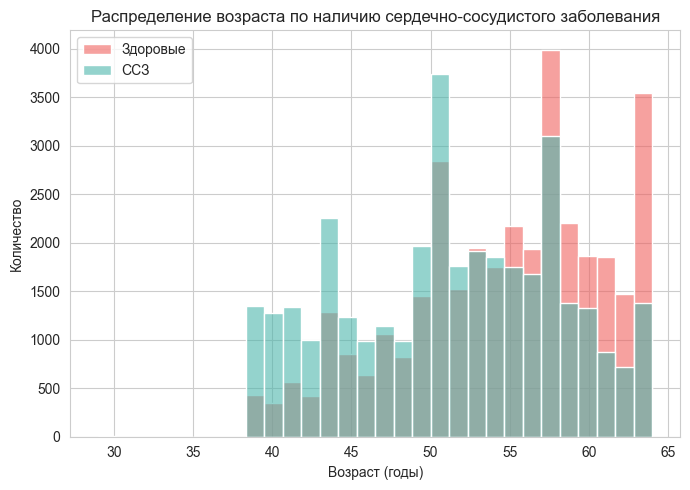

In [19]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="age_years",
    hue="cardio",
    bins=30,
    palette=["#4DB6AC", "#F0625F"],
    alpha=0.6
)

plt.title("Распределение возраста по наличию сердечно-сосудистого заболевания")
plt.xlabel("Возраст (годы)")
plt.ylabel("Количество")

plt.legend(["Здоровые", "ССЗ"])

save_and_show("age_distribution_cvd")

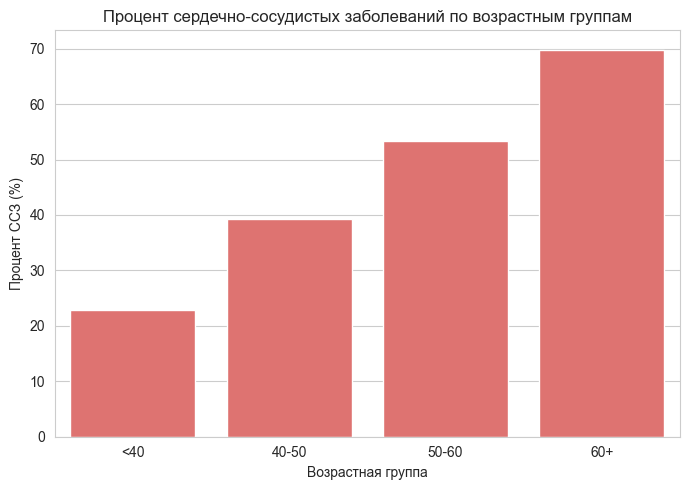

In [22]:
df["age_group"] = pd.cut(
    df["age_years"],
    bins=[0,40,50,60,100],
    labels=["<40","40-50","50-60","60+"]
)

age_rate = df.groupby("age_group")["cardio"].mean() * 100

plt.figure(figsize=(7,5))

sns.barplot(
    x=age_rate.index,
    y=age_rate.values,
    color="#F0625F"
)

plt.title("Процент сердечно-сосудистых заболеваний по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Процент ССЗ (%)")

save_and_show("cvd_rate_age_group")

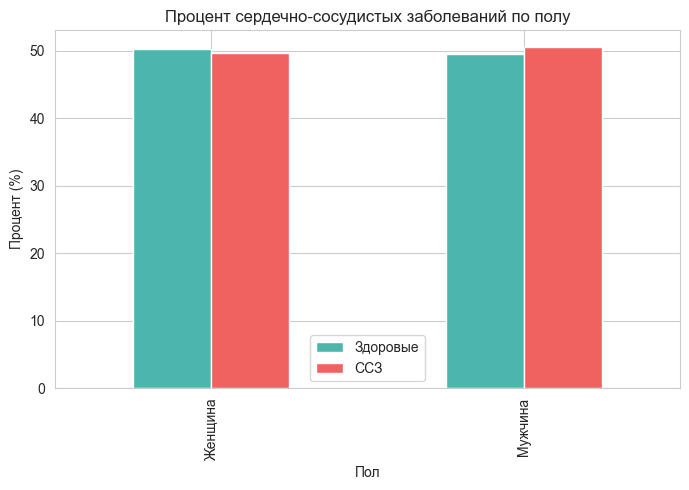

In [23]:
gender_rate = df.groupby("gender")["cardio"].mean() * 100

gender_df = pd.DataFrame({
    "gender": ["Женщина", "Мужчина"],
    "Healthy": 100 - gender_rate.values,
    "CVD": gender_rate.values
})

gender_df.set_index("gender").plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"],
    figsize=(7,5)
)

plt.title("Процент сердечно-сосудистых заболеваний по полу")
plt.xlabel("Пол")
plt.ylabel("Процент (%)")

plt.legend(["Здоровые", "ССЗ"])

save_and_show("cvd_rate_gender")

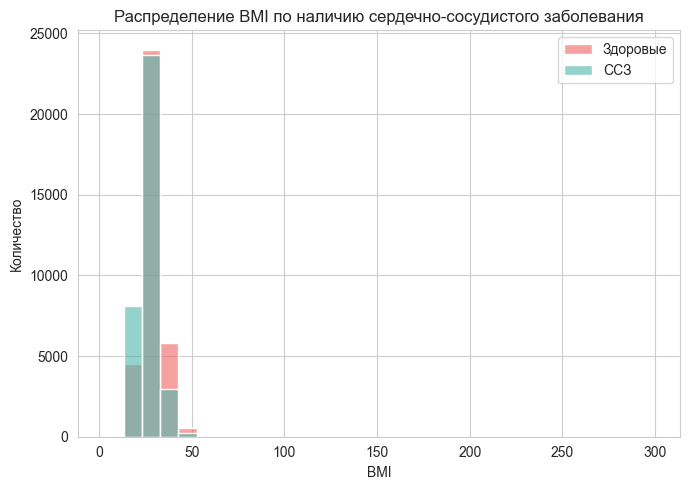

In [26]:
df["BMI"] = df["weight"] / ((df["height"]/100)**2)
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="BMI",
    hue="cardio",
    bins=30,
    palette=["#4DB6AC", "#F0625F"],
    alpha=0.6
)

plt.title("Распределение BMI по наличию сердечно-сосудистого заболевания")
plt.xlabel("BMI")
plt.ylabel("Количество")

plt.legend(["Здоровые", "ССЗ"])

save_and_show("bmi_distribution_cvd")

<Figure size 700x500 with 0 Axes>

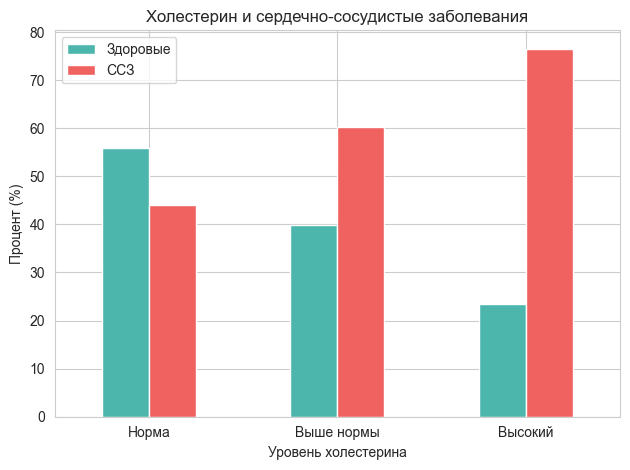

In [28]:
chol_percent = pd.crosstab(df["cholesterol"], df["cardio"], normalize="index") * 100

plt.figure(figsize=(7,5))

chol_percent.plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"]
)

plt.title("Холестерин и сердечно-сосудистые заболевания")
plt.xlabel("Уровень холестерина")
plt.ylabel("Процент (%)")

plt.xticks(
    [0,1,2],
    ["Норма","Выше нормы","Высокий"],
    rotation=0
)

plt.legend(["Здоровые","ССЗ"])

save_and_show("cholesterol_vs_cvd")

<Figure size 700x500 with 0 Axes>

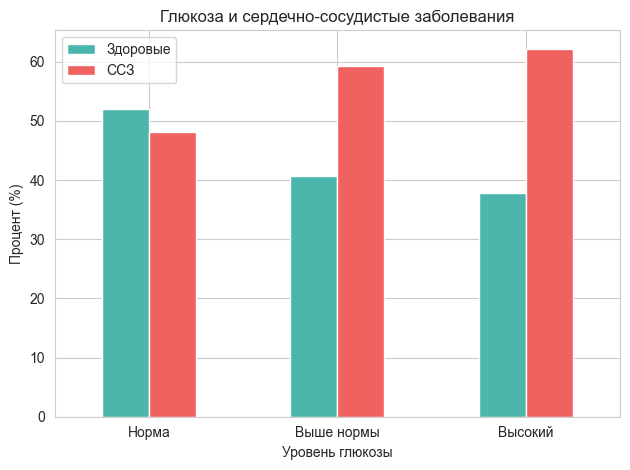

In [29]:
gluc_percent = pd.crosstab(df["gluc"], df["cardio"], normalize="index") * 100

plt.figure(figsize=(7,5))

gluc_percent.plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"]
)

plt.title("Глюкоза и сердечно-сосудистые заболевания")
plt.xlabel("Уровень глюкозы")
plt.ylabel("Процент (%)")

plt.xticks(
    [0,1,2],
    ["Норма","Выше нормы","Высокий"],
    rotation=0
)

plt.legend(["Здоровые","ССЗ"])

save_and_show("glucose_vs_cvd")

<Figure size 700x500 with 0 Axes>

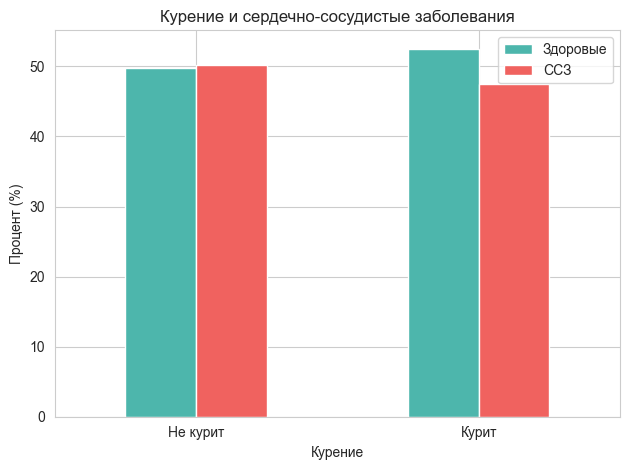

In [30]:
smoke_percent = pd.crosstab(df["smoke"], df["cardio"], normalize="index") * 100

plt.figure(figsize=(7,5))

smoke_percent.plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"]
)

plt.title("Курение и сердечно-сосудистые заболевания")
plt.xlabel("Курение")
plt.ylabel("Процент (%)")

plt.xticks(
    [0,1],
    ["Не курит","Курит"],
    rotation=0
)

plt.legend(["Здоровые","ССЗ"])

save_and_show("smoking_vs_cvd_percent")

<Figure size 700x500 with 0 Axes>

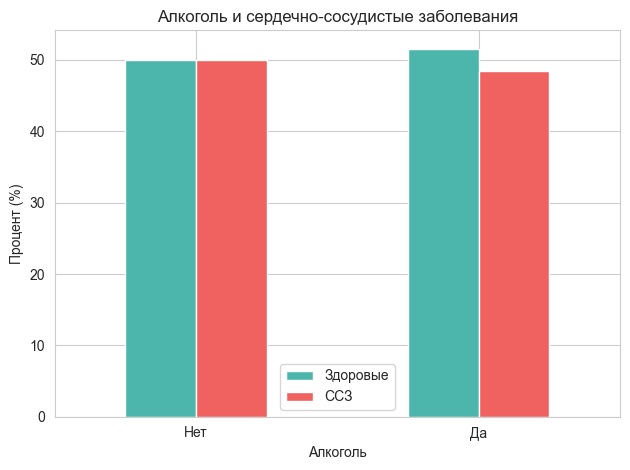

In [32]:
alco_percent = pd.crosstab(df["alco"], df["cardio"], normalize="index") * 100

plt.figure(figsize=(7,5))

alco_percent.plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"]
)

plt.title("Алкоголь и сердечно-сосудистые заболевания")
plt.xlabel("Алкоголь")
plt.ylabel("Процент (%)")

plt.xticks(
    [0,1],
    ["Нет","Да"],
    rotation=0
)

plt.legend(["Здоровые","ССЗ"])

save_and_show("alcohol_vs_cvd_percent")

<Figure size 700x500 with 0 Axes>

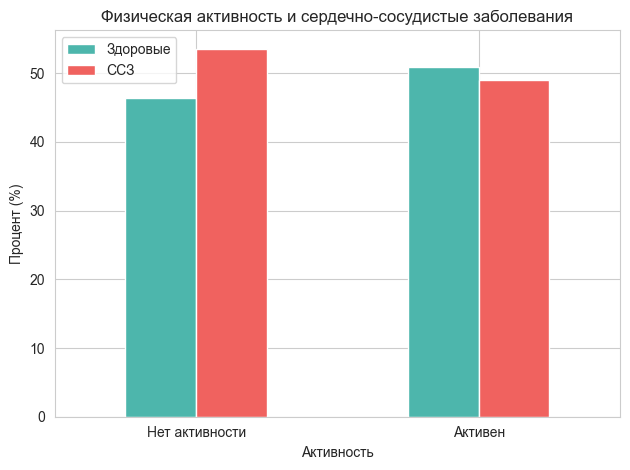

In [33]:
active_percent = pd.crosstab(df["active"], df["cardio"], normalize="index") * 100

plt.figure(figsize=(7,5))

active_percent.plot(
    kind="bar",
    color=["#4DB6AC", "#F0625F"]
)

plt.title("Физическая активность и сердечно-сосудистые заболевания")
plt.xlabel("Активность")
plt.ylabel("Процент (%)")

plt.xticks(
    [0,1],
    ["Нет активности","Активен"],
    rotation=0
)

plt.legend(["Здоровые","ССЗ"])

save_and_show("activity_vs_cvd_percent")

<h4>Матрица Корреляций</h4>

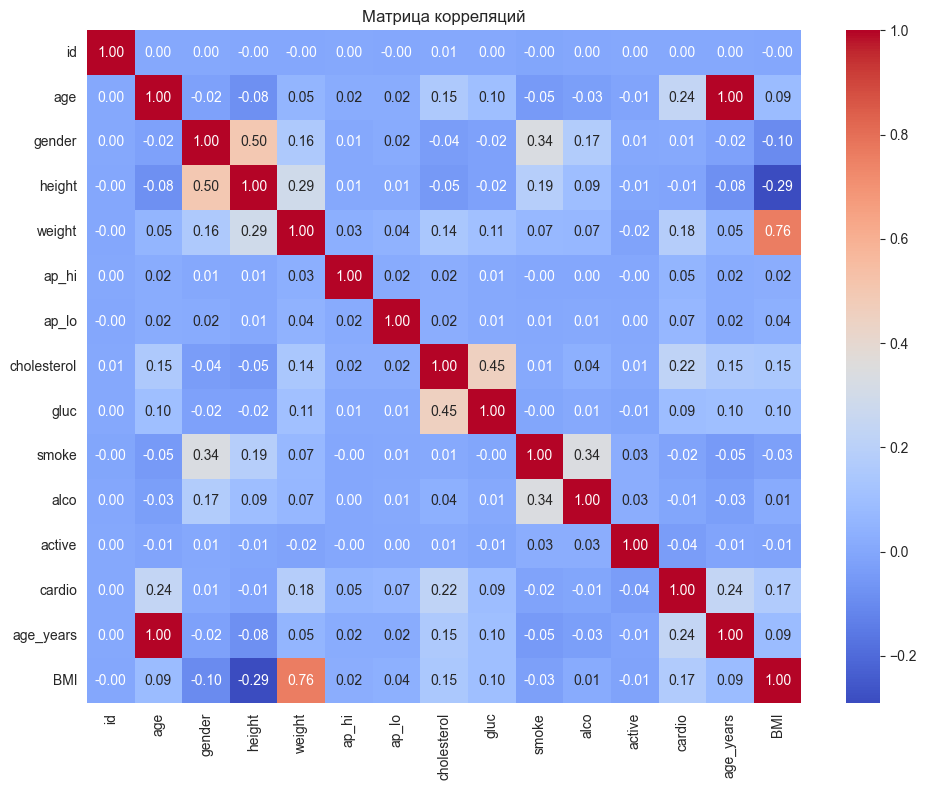

In [34]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Матрица корреляций")

save_and_show("correlation_matrix")